In [154]:
# The goal of this project is to look at land temperature and the urban spawl of Huntsville, AL
# First I need to add the data by creating a function that will read the raster data I add and clip to Huntsville
# Second I need to take that data and compare it to one another
# Third I need to compare the urbanization of huntsville from Aug 2019-Aug 2024. 

import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
from rasterio.plot import show
import geopandas as gpd
from rasterio.mask import mask
import glob
import re

In [168]:
# set data paths
boundary_path = "HuntsvilleCityLimits/Boundary_City_Huntsville_poly.shp"
LS09_data_folder = "Landsat_Data/"

# have geopandas read in the Huntsville shapefile
city = gpd.read_file(boundary_path)

In [169]:
# find only the TIF files that have b10
b10_tif_files = glob.glob(LS09_data_folder + "*B10.TIF")
b10_tif_files

['Landsat_Data\\LC08_L2SP_020036_20190815_20200827_02_T1_ST_B10.TIF',
 'Landsat_Data\\LC08_L2SP_020036_20230826_20230905_02_T1_ST_B10.TIF',
 'Landsat_Data\\LC08_L2SP_020036_20240828_20240905_02_T1_ST_B10.TIF',
 'Landsat_Data\\LC09_L2SP_020036_20220831_20230331_02_T1_ST_B10.TIF']

In [170]:
# temp = os.path.join(LS09_data_folder, "LC08_L2SP_020036_20190815_20200827_02_T1_ST_B10.TIF")

In [176]:
def clip_to_city(tif_path, boundary):
    '''
    Defining a function that will take the TIF we put in and clip it to the Huntsville city limits shapefile
    '''
    # clip the tif to the boundary
    with rasterio.open(tif_path) as src:
        # reproject the city to the same coordinates as the TIF. Without this, the two did not line up
        boundary = boundary.to_crs(src.crs)

        # https://rasterio.readthedocs.io/en/latest/api/rasterio.mask.html
        clipped, clipped_transform = mask(src, shapes=boundary.geometry, crop=True)

    return clipped[0], clipped_transform

    # fig, ax = plt.subplots(figsize = (10, 10))
    # show(clipped, transform=clipped_transform, ax=ax, title=tif_path.split("\\")[-1])

In [177]:
def extract_year(path):
    '''
    Defining a function that will extract the year out of a filename
    '''
    # google helped me with this
    match = re.search(r'_(\d{4})\d{4}_', os.path.basename(path))
    return int(match.group(1))

def get_path(b10_path, desired_band):
    '''
    Defining a function to get the b4 and b5 tif file paths, substituting them from the b10 one
    '''
    return re.sub(r'ST_B10\.TIF$', f'SR_{desired_band}.TIF', b10_path)

In [178]:
def compute_ndvi(b4, b5):
    '''
    Defining a function to calculate the NDVI based off of the bands for each year
    '''
    # to fix divide by 0 errors
    b4 = np.where(b4 == 0, np.nan, b4)
    b5 = np.where(b5 == 0, np.nan, b5)
    denom = (b5 + b4)
    return np.where(denom != 0, (b5 - b4) / denom, np.nan)

In [179]:
# a dictionary that is used to create a for loop to go through all of the data that we provide using the functions created
years_data = {}

for b10_path in b10_tif_files:
    b4_path = get_path(b10_path, "B4")
    b5_path = get_path(b10_path, "B5")
    lst, transform = clip_to_city(b10_path, city)
    b4, _ = clip_to_city(b4_path, city)
    b5, _ = clip_to_city(b5_path, city)
    ndvi = compute_ndvi(b4, b5)

    # plot the ndvi
    # fig, ax = plt.subplots(figsize=(8, 8))
    # im = ax.imshow(ndvi)
    year = extract_year(b10_path)
    years_data[year] = {"ndvi":ndvi, "lst":lst, "transform": transform}

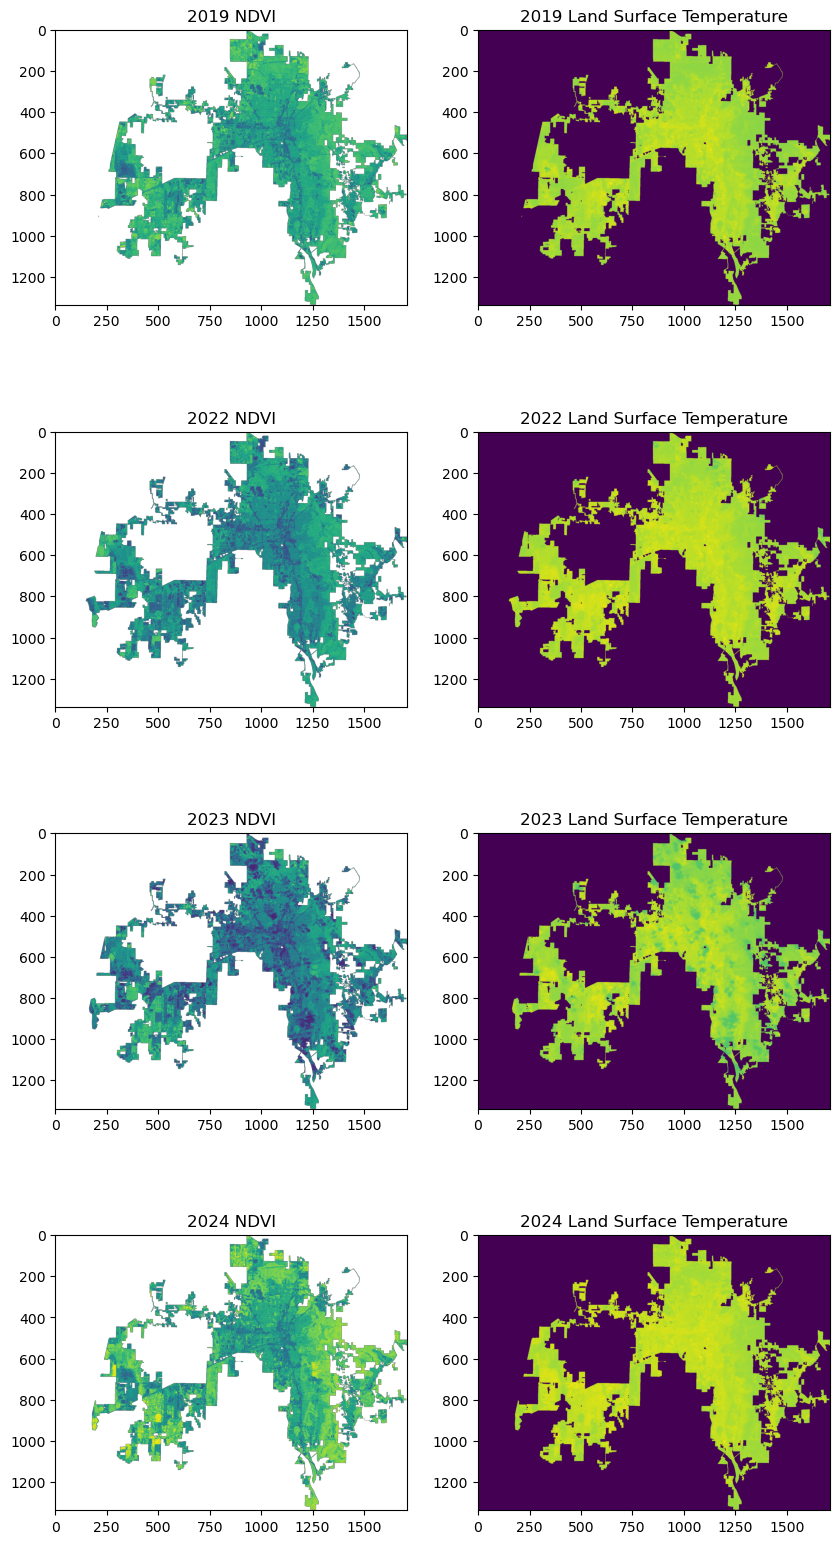

In [186]:
# The original data was out of order, so to get the figure to be numerically sorted by year, I had to sort the dictionary
sorted_years = sorted(years_data.keys())
num_years = len(sorted_years)

# Plot each year with the NDVI and temperature maps right next to each other
# figsize chosen experimentally
fig, ax = plt.subplots(num_years, 2, figsize=(10,5*num_years))

# to avoid blanks due to missing years, enumerate renumbers the data years to use as rows
# for year in sorted_years:
for row, year in enumerate(sorted_years):
    data = years_data[year]
    
    ax_ndvi = ax[row][0]
    im1 = ax_ndvi.imshow(data["ndvi"])
    ax_ndvi.set_title(f"{year} NDVI")

    ax_lst = ax[row][1]
    im2 = ax_lst.imshow(data["lst"])
    ax_lst.set_title(f"{year} Land Surface Temperature")
    
plt.show()